In [123]:
# needs to be added because other modules are not reloaded automatically. Changes would not be effective otherwise.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [124]:
import os
import sys
import importlib

# detect location of notebook
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("evaluation.ipynb"))
print("Notebook directory:", NOTEBOOK_DIR)

# Set working directory to the notebook folder
os.chdir(NOTEBOOK_DIR)

# Add the project root to sys.path so imports work
project_root = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
print("Project root added to sys.path:", project_root)

Notebook directory: /home/aronw/Development/Clans-3D/Scores_Evaluation
Project root added to sys.path: /home/aronw/Development/Clans-3D


In [125]:
from Dataset_Generator.DatasetGenerator import DatasetGenerator
from old_clans.utils_old_clans import run_clans_headless
from fasta2PDB import *
from StructSimComputer import StructSimComputer
from ClansFileGenerator import ClansFileGenerator
from ClansFile import ClansFile
from ToolType import ToolType
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import networkx as nx

In [126]:
PATH_TO_RECOVERED_CLANS = "/home/aronw/Development/clans-recovered" # path to recovered clans
CLUSTER_ROUNDS = 100000 # sets the number of rounds for clustering in recovered clans

In [ ]:
class ScoresEvaluator:
    """
    This class is responsible for evaluating the structure similarity scores by comparing them to sequence similarity scores.
    The datasets used for the evaluation are generated with the DatasetGenerator class with the given seeds.
    With the generated data, the structure similarity scores and sequence similarity scores are computed and clans files anre generated.
    The comparison is done with the scores as well as with inferred graphs and clusters.
    """
    def __init__(self, number_of_datasets, size_of_datasets, seeds, path_to_recovered_clans: str = PATH_TO_RECOVERED_CLANS):
        self._check_for_correct_input(number_of_datasets, seeds)
        self.size_of_datasets = size_of_datasets
        self.working_dir = NOTEBOOK_DIR
        self._set_up_dirs()
        self.dataset_generator = DatasetGenerator(self.generated_datasets_dir) 
        self.scores_computer = StructSimComputer()
        self.tool_type = ToolType.FOLDSEEK
        self.struct_clans_generator = ClansFileGenerator(self.clans_files_structsim_dir)
        self.seq_clans_generator = ClansFileGenerator(self.clans_files_seqsim_dir) 
        self.path_to_recovered_clans = path_to_recovered_clans
        
        
    def _set_up_dirs(self):
        """
        Sets up the necessary directories for the evaluation.
        Creates directories for generated datasets, pdbs, clans files and blast files.
        Deletes the content of the directories if they already exist.
        """
        abs_path_working_dir = os.path.abspath(self.working_dir)
        self.generated_datasets_dir = f"{abs_path_working_dir}/generated_datasets"
        self.pdbs_dir = f"{abs_path_working_dir}/PDBs"
        self.clans_files_structsim_dir = f"{abs_path_working_dir}/clans_files_structsim" # dir for clans files generated with structure similarity scores
        self.clans_files_seqsim_dir = f"{abs_path_working_dir}/clans_files_seqsim" # dir for clans files generated with sequence similarity scores
        self.blast_dir = f"{abs_path_working_dir}/blast_files"
        for dir_path in [self.generated_datasets_dir, self.pdbs_dir, self.clans_files_structsim_dir, self.blast_dir, self.clans_files_seqsim_dir]:
            delete_dir_content(dir_path)


    def _initialize_evaluation(self):
        """
        Generates datasets (fasta_files), downloads the corresponding PDB files, computes structure similarity scores and creates clans files from those.
        After it runs the old recovered clans on the generated clans files and saves the updated clans files.
        This function should be called before running the actual evaluation.
        """
        print("Initializing evaluation...")
        self._generate_datasets(self.number_of_datasets, self.size_of_datasets, self.seeds)
        self._download_pdbs(self.generated_datasets_dir, self.pdbs_dir)
        scores_for_each_dataset = self._compute_scores(self.pdbs_dir, self.number_of_datasets)
        self._compute_clans_files(scores_for_each_dataset, self.generated_datasets_dir, self.number_of_datasets)
        print("Running recovered clans.jar on the generated structural clans files...")
        input_output_dict_structural = self._generate_input_output_files_dict(self.clans_files_structsim_dir, self.clans_files_structsim_dir)
        run_clans_headless(self.path_to_recovered_clans, input_output_dict_structural, input_file_type="clans", rounds=CLUSTER_ROUNDS)
        print("Running recovered clans.jar with sequences similarity scores...")
        input_output_dict_sequence = self._generate_input_output_files_dict(self.generated_datasets_dir, self.clans_files_seqsim_dir)
        run_clans_headless(self.path_to_recovered_clans, input_output_dict_sequence, input_file_type="fasta", blast_dir=self.blast_dir, clans_generator=self.seq_clans_generator, rounds=CLUSTER_ROUNDS)
        print("Evaluation initialized. Clans files generated and clustered for each dataset with structure similarity scores and sequence similarity scores.")
    
    
    def evaluate(self, structural_to_sequence_clans_files: dict):
        """
        Evaluates the clustered clans files generated with structure similarity scores and sequence similarity scores.
        Returns a dataframe with the evaluation results consisting of numerical comparison, graph comparison and cluster comparison.
        Args:
            structural_to_sequence_clans_files: A dictionary mapping structural clans file paths to sequence clans file paths.
        """
        df_evaluation_results = []
        df_numerical_comparisons = pd.DataFrame()
        figures = []
        for struct_clans_file, seq_clans_file in structural_to_sequence_clans_files.items():
            print(f"Evaluating structural clans file {struct_clans_file} with sequence clans file {seq_clans_file}...")
            parsed_struct_clans_file = ClansFileGenerator.parse_clans_file(struct_clans_file)
            parsed_seq_clans_file = ClansFileGenerator.parse_clans_file(seq_clans_file)
            merged_scores_df, merged_coordinates_df = self._prepare_scores(parsed_struct_clans_file, parsed_seq_clans_file)
            print(merged_scores_df, merged_coordinates_df)
            
            # numerical evaluation
            figures.append(self._plot_similarity_scatter(merged_scores_df, x_col="score_struct_log10_min-max-scaled", y_col="score_seq_log10_min-max-scaled", prevent_display=False))
            df_numerical_comparison = self._compare_numerically(merged_scores_df, ["score_struct_log10", "score_seq_log10"])
            df_numerical_comparisons = pd.concat([df_numerical_comparisons, df_numerical_comparison], ignore_index=True)
            
            # graph evaluation
            coordinates_for_struct = merged_coordinates_df[["PDBchain1", "x_struct", "y_struct", "z_struct"]]
            coordinates_for_seq = merged_coordinates_df[["PDBchain1", "x_seq", "y_seq", "z_seq"]]
            G_struct = self._build_graph_from_scores(merged_scores_df[["PDBchain1", "PDBchain2", "score_struct"]], coordinates_for_struct)
            G_seq = self._build_graph_from_scores(merged_scores_df[["PDBchain1", "PDBchain2", "score_seq"]], coordinates_for_seq)
            #df_graph_comparison = self._compare_graphs(G_struct, G_seq)
            
        print("Evaluation completed.")
        self._display_evaluation_results(df_numerical_comparisons, figures)
        return df_evaluation_results
        
        
    def _display_evaluation_results(self, df_numerical_comparisons, figures):
        print("Scatterplots: ")
        for fig in figures:
            fig
        print("Numerical comparison results:")
        print(df_numerical_comparisons)
        # add further results here:
    
    
    def _prepare_scores(self, struct_clans_file: ClansFile, seq_clans_file: ClansFile) -> tuple[pd.DataFrame, pd.DataFrame]:
        """
        Prepares the scores of parsed clans file for further analyis. On of the Clans files should contain structural scores and the other sequence-based scores.
        It merges the scores into one DataFrame,
        log-transforms and normalizes the scores (min-max-scaling and z-scores are computed).

        Args:
            struct_clans_file (ClansFile): A ClansFile Object based on structural similarity.
            seq_clans_file (ClansFile): A ClansFIle Object based on sequence similarity.

        Returns:
            pd.DataFrame: A DataFrame containing the original scores of both ClansFiles,
            log-transformed scores, min-max scaled-scores and z-scores and a DataFrame containing the coordinates for each PDBchain.
        """
        merged_scores_df, merged_coordinates = self._get_merged_scores_and_cooridinates_df(struct_clans_file, seq_clans_file)
        merged_scores_df = self._log_transform(merged_scores_df, ["score_struct", "score_seq"])
        merged_scores_df = self._normalize_scores(merged_scores_df, ["score_struct_log10", "score_seq_log10"], "z-score")
        merged_scores_df = self._normalize_scores(merged_scores_df, ["score_struct_log10", "score_seq_log10"], "min-max")
        return merged_scores_df, merged_coordinates
        
        
    def _normalize_scores(self, df: pd.DataFrame, columns: list, norm_type: str) -> pd.DataFrame: 
        """
        Normalizes the given columns of the given dataframe with the specified normalization-types.

        Args:
            df: Dataframe containing columns with scores.
            columns: Names of columns which should be normalized.
            norm_type: Type of normalization for each column in columns. Possible values are "min-max" and "z-score"

        Returns:
            The df with normalized scores.
        """
        df_norm = df.copy()
        for col in columns:
            if col not in df_norm.columns:
                raise ValueError(f"Column '{col}' not found in DataFrame.")
            series = df_norm[col]
            if norm_type == "min-max":
                df_norm[col + "_min-max-scaled"] = self._normalize_min_max(series)
            elif norm_type == "z-score":
                df_norm[col + "_z-scores"] = self._normalize_to_z_scores(series)
            else:
                raise ValueError(f"Unsupported normalization type '{norm_type}'. "
                                "Use 'min-max' or 'z-score'.")
        return df_norm


    def _log_transform(self, df: pd.DataFrame, columns: list, base: float = 10) -> pd.DataFrame:
        """
        Log-transforms the specified columns of a Pandas DataFrame using a given logarithm base.
        Automatically handles zeros and non-positive values by replacing them with the smallest positive float.

        Args:
            df (pd.DataFrame): The DataFrame containing columns to be transformed.
            columns (list): List of column names to be log-transformed.
            base (float): The logarithm base (default: 10).

        Returns:
            pd.DataFrame: A copy of the input DataFrame with additional log-transformed columns.
                        Each transformed column is named '<original>_log<base>'.
        """
        df_log = df.copy()
        for col in columns:
            if col not in df_log.columns:
                raise ValueError(f"Column '{col}' not found in DataFrame.")
            # Replace zeros or negatives with smallest positive float to avoid log(0)
            series = df_log[col]
            safe_series = series.copy()
            safe_series[safe_series <= 0] = np.nextafter(0, 1)
            if base == 10:
                transformed = -np.log10(safe_series)
            elif base == np.e:
                transformed = -np.log(safe_series)
            else:
                transformed = -np.log(safe_series) / np.log(base)

            # Add new column
            new_col_name = f"{col}_log{base}"
            df_log[new_col_name] = pd.Series(transformed, index=df_log.index, name=new_col_name)
        return df_log
    
    
    def _normalize_min_max(self, scores: pd.Series) -> pd.Series:
        """
        Normalizes a given Pandas Series with min-max scaling.

        Args:
            scores (pd.Series): A Series containing scores.

        Returns:
            scores_norm: A Series containing normalized (min-max scaled) scores.
        """
        min_val, max_val = scores.min(), scores.max()
        if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
            scores_norm = scores # avoid divide-by-zero
        else:
            scores_norm = (scores - min_val) / (max_val - min_val)
        return scores_norm
        
        
    def _normalize_to_z_scores(self, scores: pd.Series) -> pd.Series:
        """
        Normalizes a given Pandas Series to z-scores.

        Args:
            scores (pd.Series): A Series containing scores.

        Returns:
            scores_norm: A Series containing normalized (z-score) scores.
        """
        mean, std = scores.mean(), scores.std()
        if pd.isna(std) or std == 0:
            scores_norm = scores
        else:
            scores_norm = (scores - mean) / std
        return scores_norm
    
    
    def _plot_similarity_scatter(self, df, x_col='score_struct', y_col='score_seq', title='Structural vs Sequence Similarity', prevent_display=False):
        """
        Create a scatter plot with a regression line between two columns of a DataFrame.
        Args:
            df (pd.DataFrame): The DataFrame containing the data.
            x_col (str): The name of the column to be plotted on the x-axis.
            y_col (str): The name of the column to be plotted on the y-axis.
            title (str): The title of the plot.
        Returns:
            matplotlib.figure.Figure: The generated scatter plot with regression line which can be displayed or saved.
        """
        fig, ax = plt.subplots(figsize=(6, 6))
        sns.regplot(
            data=df,
            x=x_col,
            y=y_col,
            scatter_kws={'alpha': 0.6, 's': 40},
            line_kws={'color': 'red'},
            ax=ax
        )
        ax.set_title(title)
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())
        ax.grid(True)
        if prevent_display:
            plt.close(fig)  # prevent immediate display in notebooks
        return fig
        

    def _compare_numerically(self, df_combined: pd.DataFrame, columns: list) -> pd.DataFrame:
        """
        Compares the scores of 2 given columns numerically.
        Returns a dataframe with the comparison results.
        The scores of the given columns are compared with the metrics: 
        Correlation(Spearman and Pearson), RMSD
        Args:
            df_combined: A dataframe with the merged scores of the structural clans file and the sequence clans file.
            columns: A list of 2 columns contained in df_combined.
        Returns:
            df_results: A dataframe containg Correlation(Spearman and Pearson) and RMSD values for the scores of the given columns.
        """
        df_combined = df_combined[columns].apply(pd.to_numeric)
        spearman_corr = df_combined[columns[0]].corr(df_combined[columns[1]], method='spearman')
        pearson_corr = df_combined[columns[0]].corr(df_combined[columns[1]], method='pearson')
        rmsd = ((df_combined[columns[0]] - df_combined[columns[1]]) ** 2).mean() ** 0.5
        df_results = pd.DataFrame({
            'spearman_correlation': [spearman_corr],
            'pearson_correlation': [pearson_corr],
            'rmsd': [rmsd]
        })
        return df_results
    
    
    def _compare_graphs(self, G_1, G_2):
        """
        Compares the graphs inferred from the structural clans file with the graphs inferred from the sequence clans file.
        Returns a dataframe with the comparison results.
        """
        
        raise NotImplementedError("Graph comparison not implemented yet.")
    

    def _build_graph_from_scores(self, df, coords_df):
        """
        Builds a 3D graph (NetworkX) from pairwise score data and node coordinates.

        Args:
            df (pd.DataFrame): DataFrame containing columns f.e. [PDBchain1, PDBchain2, score]
            coords_df (pd.DataFrame): DataFrame containing columns [PDBchain, x, y, z]

        Returns:
            networkx.Graph: Graph where nodes represent PDB chains and edges represent pairwise scores.
                            Each node has a 'pos' attribute with 3D coordinates (x, y, z).
        """
        G = nx.Graph()
        for _, row in df.iterrows():
            G.add_edge(
                row.iloc[0], # node_x
                row.iloc[1], # node_y
                weight=row.iloc[2] # edge_length
            )
        coords_dict = dict(zip(coords_df.iloc[:, 0], 
                           zip(coords_df.iloc[:, 1], coords_df.iloc[:, 2], coords_df.iloc[:, 3])))
        nx.set_node_attributes(G, coords_dict, name="pos")
        return G
    
    
    def _compare_clusters(self, struct_clans_file: ClansFile, seq_clans_file: ClansFile):
        """
        Compares the clusters inferred from the structural clans file with the clusters inferred from the sequence clans file.
        Returns a dataframe with the comparison results.
        """
        raise NotImplementedError("Cluster comparison not implemented yet.")
    
    
    def _get_merged_scores_and_cooridinates_df(self, struct_clans_file: ClansFile, seq_clans_file: ClansFile):
        """
        Merges the scores of the structural clans file with the scores of the sequence clans file.
        Returns a dataframe with the merged scores.
        Args:
            struct_clans_file: A ClansFile object containing the structural scores.
            seq_clans_file: A ClansFile object containing the sequence scores.
        Returns:
            A list of dataframes. One with the merged scores with the first column for structural scores and the second column for sequence scores.
            And one for the cooridinates with each row representing the cooridantes of each PDBchain of the dataset.
        """
        structural_scores = struct_clans_file.scores
        structural_coordinates = struct_clans_file.get_coordinates()
        sequence_scores = seq_clans_file.scores
        sequence_coordinates = seq_clans_file.get_coordinates()
        merged_coordinates = pd.merge(structural_coordinates, sequence_coordinates, on=["PDBchain1"], suffixes=('_struct', '_seq'))
        merged_scores = pd.merge(structural_scores, sequence_scores, on=['PDBchain1', 'PDBchain2'], suffixes=('_struct', '_seq'))
        merged_scores = merged_scores[["PDBchain1", "PDBchain2", "score_struct", "score_seq"]].apply(pd.to_numeric, errors='coerce')
        return merged_scores, merged_coordinates
    
    
    def match_clans_files_for_comparison(self, structural_clans_dir, sequence_clans_dir):
        """
        This method matches the clans files generated with structure similarity scores to the clans files generated with sequence similarity scores.
        It returns a dictionary which maps the structural clans file path to the sequence clans file path.
        """
        structural_to_sequence = {}
        for struct_file in os.listdir(structural_clans_dir):
            if not struct_file.endswith("_out.clans"):
                continue
            seq_file = struct_file
            structural_to_sequence[os.path.join(structural_clans_dir, struct_file)] = os.path.join(sequence_clans_dir, seq_file)
        return structural_to_sequence


    def _generate_input_output_files_dict(self, input_files_dir, output_files_dir):
        """
        Generates a dictionary mapping input files to output files.
        It appends "_out" to the output file names.
        Args:
            input_files_dir: Directory containing the input files.
            output_files_dir: Directory where the output files will be saved.
        Returns:
            dict: A dictionary mapping absolute input file paths to absolute output file paths.
        """
        input_output_files = {}

        for file in os.listdir(input_files_dir):
            # only use files that contain "cleaned" in the name
            if "cleaned" not in file:
                continue

            base_name = os.path.splitext(file)[0]
            output_file_name = f"{base_name}_out.clans"

            input_file_path = os.path.abspath(os.path.join(input_files_dir, file))
            output_file_path = os.path.abspath(os.path.join(output_files_dir, output_file_name))

            input_output_files[input_file_path] = output_file_path

        return input_output_files


    def _compute_clans_files(self, scores_for_each_dataset: dict, generated_datasets_dir, number_of_datasets):
        """
        Generates clans files for each dataset based on the computed scores.

        Args:
            scores_for_each_dataset (dict): A dictionary containing the scores for each dataset.
            generated_datasets_dir: A path to the generated datasets
            number_of_datasets: number of generated datasets
        """
        for i in range(number_of_datasets):
            cleaned_dataset_i_path = os.path.join(generated_datasets_dir, f"dataset_{i+1}_cleaned.fasta")
            self.struct_clans_generator.generate_clans_file(scores_for_each_dataset[i], cleaned_dataset_i_path)

    
    def _compute_scores(self, pdbs, number_of_datasets):
        """
        Computes the structure similarity scores for the generated datasets.
        
        Args:
            pdbs: A directory with directorys of pdbs for each dataset
        Returns:
            dict: A dictionary containing the scores for each dataset.
        """
        scores = {}
        for i in range(number_of_datasets):
            pdb_dir_for_dataset = os.path.join(pdbs, f"dataset_{i+1}")
            print(f"Computing scores for dataset {i+1}/{number_of_datasets}...")
            scores[i] = self.scores_computer.run(self.tool_type, pdb_dir_for_dataset)
        return scores


    def _download_pdbs(self, generated_datasets_dir, out_dir):
        """
        Downloads the PDB files for the generated datasets.
        For each dataset, the corresponding PDB files are downloaded in a separated directory in the self.pdbs_dir.
        Args:
            path_to_datasets: path to the datasets for which to download the corresponding pdbs
            out_dir: path to the directory where the pdbs are saved
        """
        print("Downloading PDB files for the generated datasets...")
        dataset_files = [f for f in os.listdir(generated_datasets_dir) if f.endswith(".fasta")]
        for i in range(len(dataset_files)):
            dataset_path = os.path.join(generated_datasets_dir,f"dataset_{i+1}.fasta")
            # create pdb dir for each dataset
            pdb_dir_for_dataset = os.path.join(out_dir, f"dataset_{i+1}")
            delete_dir_content(pdb_dir_for_dataset)
            print(f"Downloading PDB files for dataset dataset_{i+1}...")
            fetch_pdbs(dataset_path, pdb_dir_for_dataset)
    
    
    def _generate_datasets(self, n, size, seeds):
        """
        Generates n datasets (fasta_files) by calling the dataset generator.
        The datasets are saved in the out_dir.
        
        Args
            n: number of datasets to generate
            size: size of each dataset
            seeds: seed sequences for the Dataset-Generator
            out_dir: directory where to save the datasets
        """
        n_cl_per_dataset = len(seeds) // n
        print(f"Generating {n} datasets with {size} sequences each...")
        for i in range(n):
            print(f"Generating dataset {i+1}/{n}...")
            seeds_for_current_dataset = seeds[i*n_cl_per_dataset:(i+1)*n_cl_per_dataset]
            self.dataset_generator.generate(size, n_cl_per_dataset, seeds_for_current_dataset, f"dataset_{i+1}.fasta")


    def _check_for_correct_input(self, number_of_datasets, seeds):
        """Checks if the input parameters are correct.

        Raises:
            ValueError: If number_of_datasets is less than or equal to 0.
            ValueError: If the number of seeds is less than the number of datasets.

        Returns:
            None
        """
        if number_of_datasets <= 0:
            raise ValueError("Number of datasets must be greater than 0.")
        elif len(seeds) < number_of_datasets:
            raise ValueError("Number of seeds must be greater than or equal to number of datasets.")
        else:
            self.number_of_datasets = number_of_datasets
            self.seeds = seeds

In [128]:
# test-seeds ["P68871", "Q99895", "P42212", "P00734", "P69905", "P0A6F5"]
evaluator = ScoresEvaluator(3, 30,  ["P68871", "Q99895", "P42212", "P00734", "P69905", "P0A6F5"])

In [129]:
#evaluator._initialize_evaluation()

Evaluating structural clans file ../../clans_files_structsim/dataset_1_cleaned_out.clans with sequence clans file ../../clans_files_seqsim/dataset_1_cleaned_out.clans...
Parsing CLANS file ../../clans_files_structsim/dataset_1_cleaned_out.clans...
Parsing CLANS file ../../clans_files_seqsim/dataset_1_cleaned_out.clans...
     PDBchain1  PDBchain2  score_struct      score_seq  score_struct_log10  \
0            4         11  1.654000e-20  4.020000e-105           19.781464   
1            4         10  4.686000e-21  3.040000e-107           20.329198   
2            4         13  3.638000e-21  3.450000e-105           20.439137   
3            4         12  1.654000e-20  6.740000e-105           19.781464   
4            4         14  1.782000e-20  9.810000e-104           19.749092   
..         ...        ...           ...            ...                 ...   
205          9         14  4.978000e-21  2.450000e-106           20.302945   
206          9         13  1.152000e-20  3.320000e-10

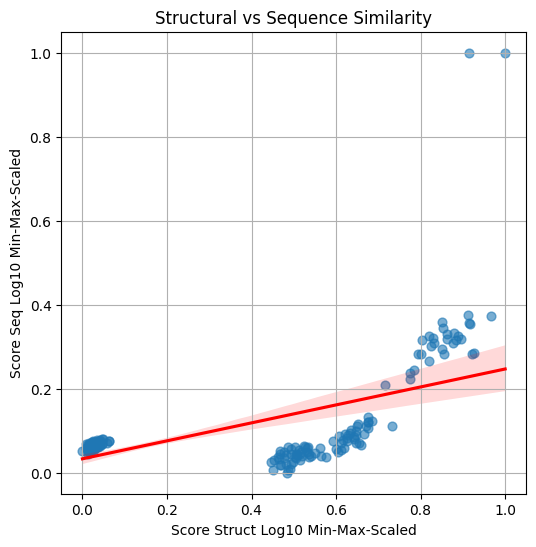

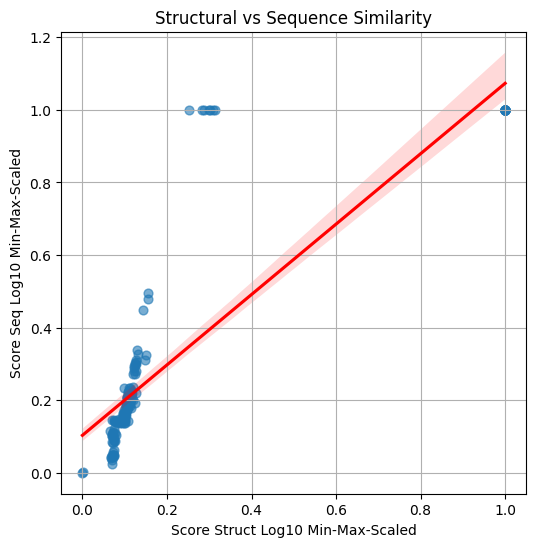

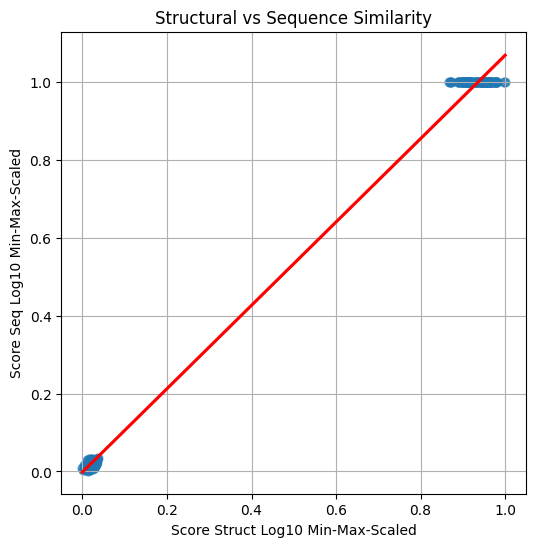

In [130]:
structural_to_sequence = evaluator.match_clans_files_for_comparison("../../clans_files_structsim", "../../clans_files_seqsim")
evaluation_results_df = evaluator.evaluate(structural_to_sequence)